In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("housing.csv")

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.shape

(20640, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [9]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [10]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False,6.281853,0.172096,2.181467


In [12]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

In [16]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [17]:
es = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 37871013888.0000 - mae: 156019.1875 - val_loss: 12600115200.0000 - val_mae: 88558.5078
Epoch 2/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 11610487808.0000 - mae: 84351.0469 - val_loss: 9710185472.0000 - val_mae: 76587.1172
Epoch 3/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 9433452544.0000 - mae: 75146.9844 - val_loss: 8118656512.0000 - val_mae: 69314.8125
Epoch 4/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8082741248.0000 - mae: 68686.7500 - val_loss: 7100728832.0000 - val_mae: 64197.8281
Epoch 5/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7166097408.0000 - mae: 63998.0625 - val_loss: 6392312832.0000 - val_mae: 60591.9023
Epoch 6/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6530704384.0000 - mae: 60501.5469 - val_loss: 5910987264.0000 - val_mae: 57116.2070
Epoch 7/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6081908224.0000 - mae: 57882.2852 - val_loss: 5672034304.0000 - v

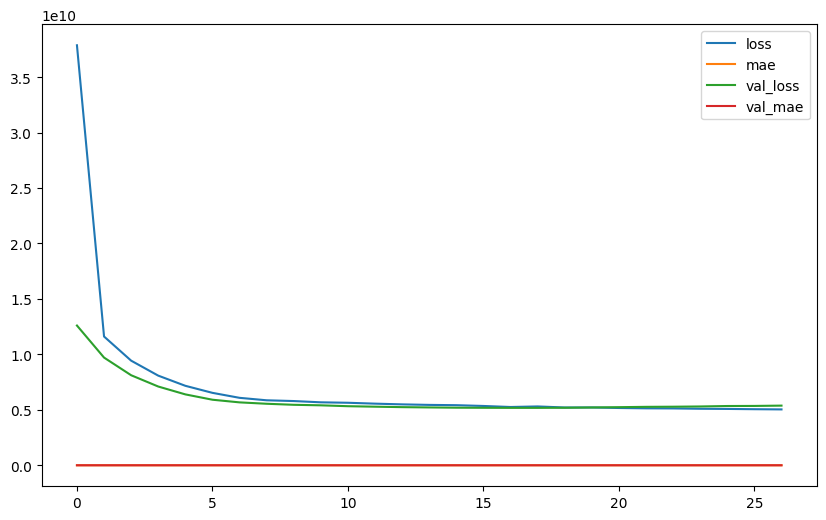

In [19]:
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.show()

In [20]:
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 50975.433416795364
MSE: 5177104191.086745
R2: 0.6049245482096346


In [22]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

print(result.head(10))

     Actual      Predicted
0   47700.0   71092.539062
1   45800.0   96573.023438
2  500001.0  243323.062500
3  218600.0  273916.500000
4  278000.0  242422.375000
5  158700.0  144160.843750
6  198200.0  290605.812500
7  157500.0  233330.531250
8  340000.0  238148.687500
9  446600.0  411198.625000


In [23]:
y = df["median_house_value"]

In [24]:
y = np.log1p(df["median_house_value"])

In [25]:
y_pred = model.predict(X_test)

y_pred = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


C:\Users\HARSHIT\AppData\Local\Temp\ipykernel_18192\2487798027.py:3: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(y_pred)
C:\Users\HARSHIT\anaconda3\envs\nlp_course_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

In [28]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, r2])

In [29]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "R2"]
)

results_df.sort_values(by="R2", ascending=False)

,Model,MAE,MSE,R2
4,XGBoost,30927.524137,2.220480e+09,0.830551
2,Random Forest,32377.423150,2.521546e+09,0.807576
3,Gradient Boosting,36591.406603,2.874713e+09,0.780625
1,Decision Tree,44241.223837,5.227384e+09,0.601088
0,Linear Regression,50888.660016,5.280716e+09,0.597018


In [30]:
import joblib

joblib.dump(model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [31]:
joblib.dump(model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [32]:
best_model = XGBRegressor()
best_model.fit(X_train, y_train)

import joblib
joblib.dump(best_model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [33]:
results_df

,Model,MAE,MSE,R2
0,Linear Regression,50888.660016,5.280716e+09,0.597018
1,Decision Tree,44241.223837,5.227384e+09,0.601088
2,Random Forest,32377.423150,2.521546e+09,0.807576
3,Gradient Boosting,36591.406603,2.874713e+09,0.780625
4,XGBoost,30927.524137,2.220480e+09,0.830551


In [34]:
print(X.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


In [4]:
print(X.shape)

NameError: name 'X' is not defined